# 2 — What separates the people who left from the people who stayed

One question, asked of the joined table notebook 01 wrote: which columns look different between
the two groups, and by how much. Nothing here is modelled and nothing here is decided.

**An association is not a cause.** A column that separates leavers from stayers may be a symptom
of leaving and not a cause of it: a person on their way out stops signing up for training. A cross-section cannot tell the two apart, and no figure below tries.

The figures use the repository's palette so that a colour means the same thing here as it does
in `reports/figures/`. The numbers they show are published, with their test and a corrected
p-value, in `reports/univariate_tests.csv` — written by `scripts/data_quality_report.py`, not by
this notebook.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from attrition_serving.analysis.eda import (
    numeric_group_stats,
    print_basic_overview,
    require_columns,
    target_distribution,
)
from attrition_serving.config import PATHS
from attrition_serving.figure_style import PALETTE, apply_style, diverging_cmap, series_colours

apply_style()

TARGET = "a_quitte_l_entreprise"
df = pd.read_parquet(PATHS.data_processed / "employees_joined.parquet")
require_columns(df, [TARGET])

print_basic_overview(df)
df.head()

Shape: (1470, 35)

Columns (first ones):
['age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente', 'eval_number_int', 'a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel', 'employee_id_anon']


,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,...,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,employee_id_anon
0,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,...,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5,emp_338e593c7e90a79d
1,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,...,1,2,8,1,Infra & Cloud,Y,Frequent,1,7,emp_89f1c49e9609aabf
2,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,...,1,4,2,2,Autre,Y,Occasionnel,0,0,emp_8b1641b2cb8432db
3,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,...,1,5,3,4,Infra & Cloud,Y,Frequent,3,0,emp_6fac8ca2e88ae968
4,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,...,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2,emp_68169193b4301586


## How imbalanced the target is

The share of leavers decides how every number below is read. At this base rate a model that
always predicts "stays" is right 84 % of the time and finds nobody, which is why accuracy
appears nowhere in this repository.

In [2]:
counts = target_distribution(df, TARGET)
pd.DataFrame({"employees": counts, "share": (counts / counts.sum()).round(3)})

,employees,share
a_quitte_l_entreprise,,
Non,1233,0.839
Oui,237,0.161


## The categorical columns

Four attributes, each as the share of its categories that left. A bar chart and not a pie:
comparing lengths from a common baseline is the one comparison the eye does well, and three of
these have more than three categories.

Read them against the overall rate, the dashed line. A category above it leaves more often than
the company as a whole; how much of that gap is sampling noise is what
`reports/univariate_tests.csv` answers for the numeric columns, and what the group sizes below
answer for these.

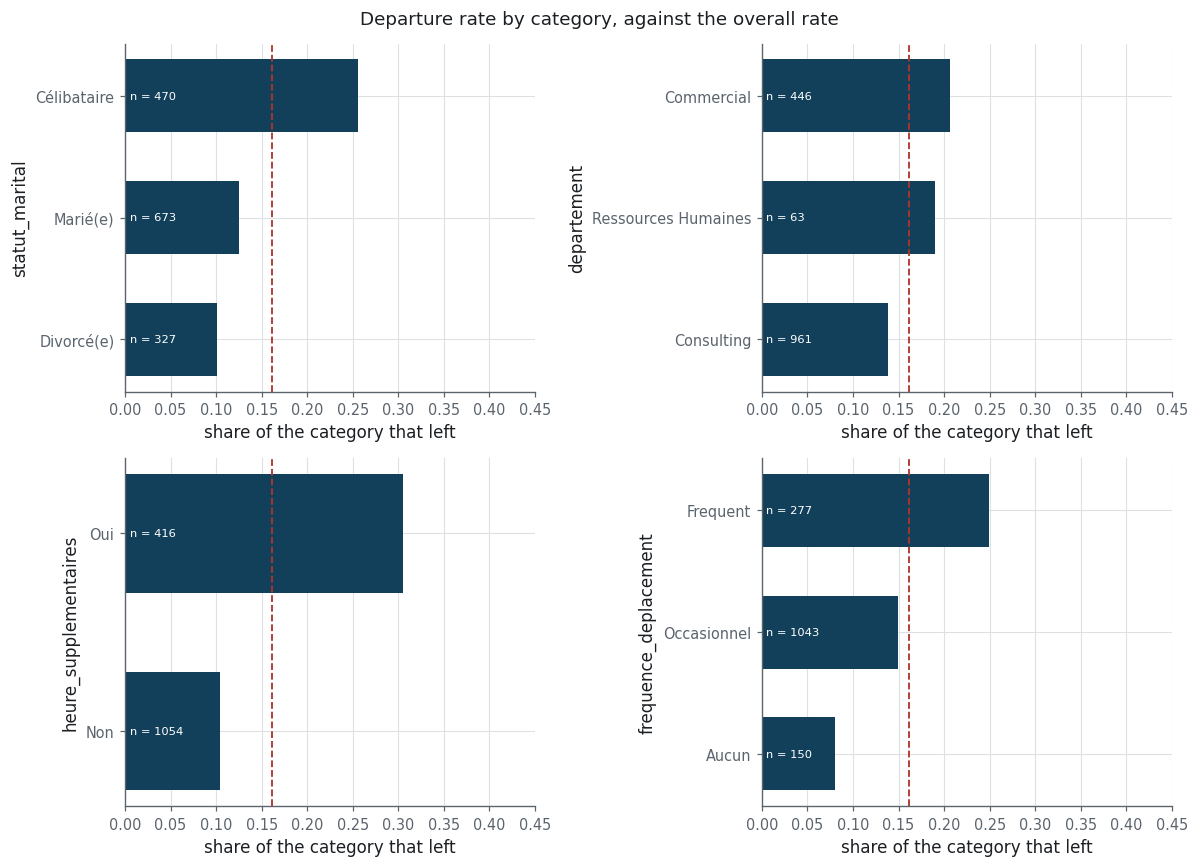

In [3]:
CATEGORICAL = ["statut_marital", "departement", "heure_supplementaires", "frequence_deplacement"]
base_rate = df[TARGET].eq("Oui").mean() if df[TARGET].dtype == object else df[TARGET].mean()

figure, axes = plt.subplots(2, 2, figsize=(11, 8))
for axis, column in zip(axes.ravel(), CATEGORICAL, strict=True):
    left = df.assign(_left=df[TARGET].eq("Oui") if df[TARGET].dtype == object else df[TARGET])
    share = left.groupby(column, observed=True)["_left"].agg(["mean", "size"]).sort_values("mean")
    axis.barh(share.index.astype(str), share["mean"], color=PALETTE["primary"], height=0.6)
    axis.axvline(base_rate, color=PALETTE["reference"], linestyle="--", linewidth=1.2)
    for position, (rate, size) in enumerate(zip(share["mean"], share["size"], strict=True)):
        axis.text(0.005, position, f"n = {size}", va="center", fontsize=7.5, color=PALETTE["paper"])
    axis.set_xlabel("share of the category that left")
    axis.set_ylabel(column)
    axis.set_xlim(0, max(0.45, share["mean"].max() * 1.15))
figure.suptitle("Departure rate by category, against the overall rate")
figure.tight_layout()
plt.show()

## The numeric columns

Four of them, chosen because they are the four the univariate tests rank highest and because
each says something different: what is earned, how long the person has been there, how far they
travel, how long since the last promotion.

The boxes say where the middle half of each group sits. Two distributions that overlap this much
do not separate anybody on their own — which is the point of showing them before any model.

C:\Users\Ben\AppData\Local\Temp\ipykernel_21388\2620071652.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  drawn = axis.boxplot(groups, labels=names, patch_artist=True, widths=0.55)
C:\Users\Ben\AppData\Local\Temp\ipykernel_21388\2620071652.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  drawn = axis.boxplot(groups, labels=names, patch_artist=True, widths=0.55)
C:\Users\Ben\AppData\Local\Temp\ipykernel_21388\2620071652.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  drawn = axis.boxplot(groups, labels=names, patch_artist=True, widths=0.55)
C:\Users\Ben\AppData\Local\Temp\ipykernel_21388\2620071652.py:14

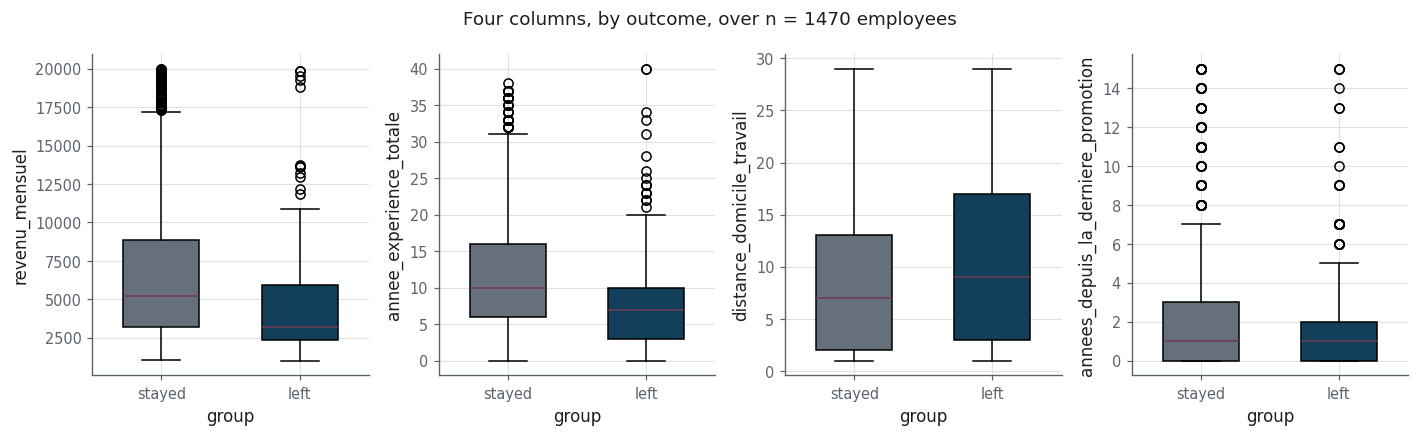

In [4]:
NUMERIC = [
    "revenu_mensuel",
    "annee_experience_totale",
    "distance_domicile_travail",
    "annees_depuis_la_derniere_promotion",
]
labels = {0: "stayed", 1: "left", "Non": "stayed", "Oui": "left"}
colours = series_colours(["stayed", "left"], control=["stayed"])

figure, axes = plt.subplots(1, 4, figsize=(13, 4))
for axis, column in zip(axes, NUMERIC, strict=True):
    groups = [df.loc[df[TARGET] == key, column].dropna() for key in sorted(df[TARGET].unique())]
    names = [labels.get(key, str(key)) for key in sorted(df[TARGET].unique())]
    drawn = axis.boxplot(groups, labels=names, patch_artist=True, widths=0.55)
    for patch, name in zip(drawn["boxes"], names, strict=True):
        patch.set_facecolor(colours[name])
    axis.set_xlabel("group")
    axis.set_ylabel(column)
figure.suptitle(f"Four columns, by outcome, over n = {len(df)} employees")
figure.tight_layout()
plt.show()

## What the columns share with each other

Two columns that carry the same information are two columns whose coefficients cannot both be
read. The pairs above 0.80 are published in `reports/redundant_features.csv`, with the decision
taken on each. They are kept: the ridge penalty absorbs the redundancy, and removing one of a
pair would silently redefine what the other's coefficient measures.

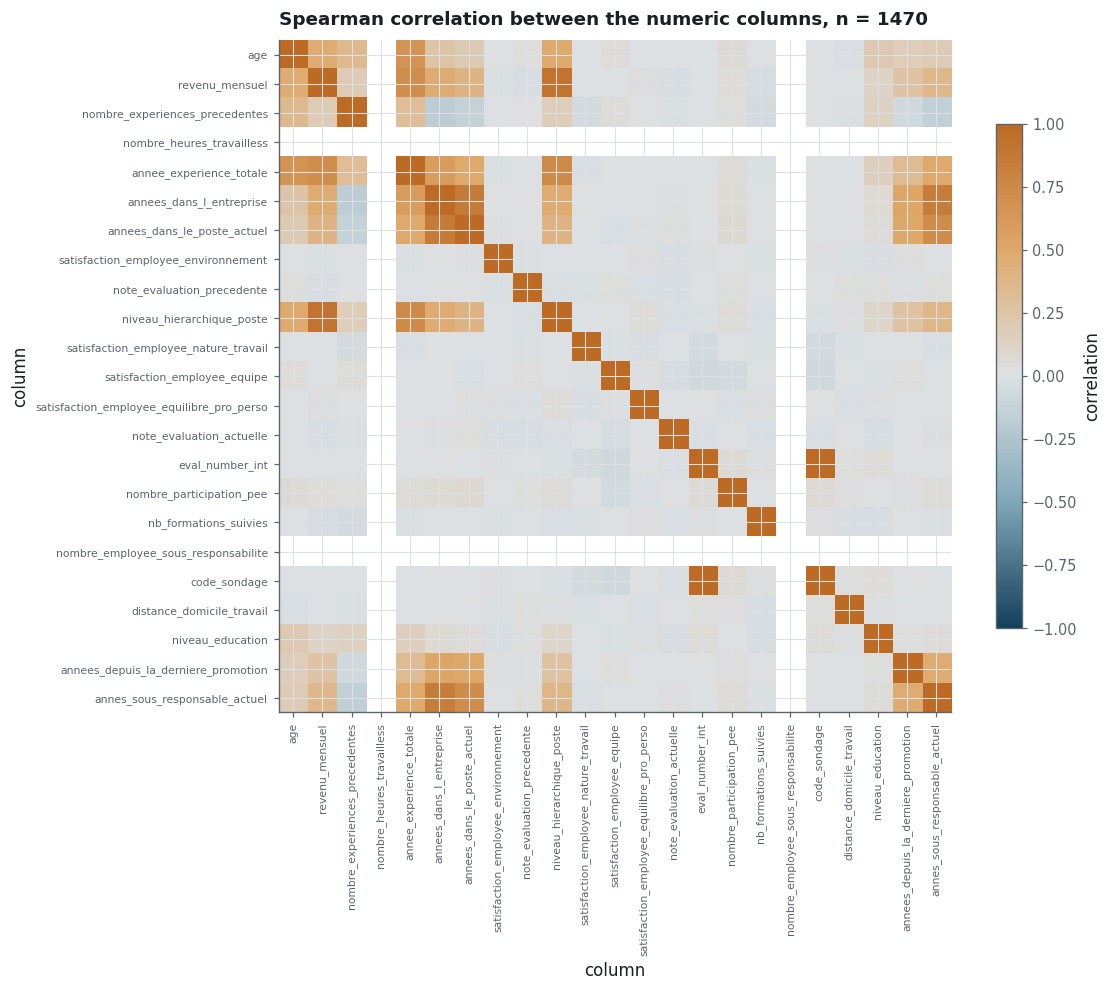

In [5]:
quantitative = [
    column for column in df.select_dtypes(include=["int64", "float64"]).columns if column != TARGET
]
correlation = df[quantitative].corr(method="spearman")

figure, axis = plt.subplots(figsize=(11, 9))
image = axis.imshow(correlation, cmap=diverging_cmap(), vmin=-1, vmax=1)
axis.set_xticks(range(len(quantitative)))
axis.set_xticklabels(quantitative, rotation=90, fontsize=7)
axis.set_yticks(range(len(quantitative)))
axis.set_yticklabels(quantitative, fontsize=7)
axis.set_xlabel("column")
axis.set_ylabel("column")
axis.set_title(f"Spearman correlation between the numeric columns, n = {len(df)}")
figure.colorbar(image, ax=axis, shrink=0.75, label="correlation")
figure.tight_layout()
plt.show()

## The same thing as a table

Means per group, for the columns the figures showed and for the ones they did not. It is the
table a reader checks a claim against, and `reports/univariate_tests.csv` carries the test that
says whether each gap survives a correction for having looked at thirty columns.

In [6]:
present = [column for column in NUMERIC + ["age", "nb_formations_suivies"] if column in df.columns]
numeric_group_stats(df, numeric_cols=present, target=TARGET)

revenu_mensuel                                          \
                               count         mean          std  median   min   
a_quitte_l_entreprise                                                          
Non                             1233  6832.739659  4818.208001  5204.0  1051   
Oui                              237  4787.092827  3640.210367  3202.0  1009   

                             annee_experience_totale                       \
                         max                   count       mean       std   
a_quitte_l_entreprise                                                       
Non                    19999                    1233  11.862936  7.760719   
Oui                    19859                     237   8.244726  7.169204   

                              ...      age                 \
                      median  ...      std median min max   
a_quitte_l_entreprise         ...                           
Non                     10.0  ...  8.88836   36.0  18  60   
Oui                      7.0  ...  9.68935   32.0  18  58   

                      nb_formations_suivies                                     
                                      count      mean       std median min max  
a_quitte_l_entreprise                                                           
Non                                    1233  2.832928  1.293585    3.0   0   6  
Oui                                     237  2.624473  1.254784    2.0   0   6  

[2 rows x 36 columns]

## What this notebook settled, and what it did not

Settled: the target is imbalanced at about 16 %, four categorical attributes separate the two
groups visibly, and several numeric columns are strongly correlated with one another.

Not settled: whether any of it predicts a departure the model has never seen. That needs a
protocol, and notebook 06 reads the one this repository ships.